# **Random Seed**

In [ ]:
import numpy as np
import tensorflow as tf
import random

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Data Preprocessing and Importing

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from keras.models import Model
from keras.layers import Input, Conv1D, LSTM, Dense, Concatenate
from keras.layers import GlobalAveragePooling1D, Multiply, Dropout
from keras.layers import BatchNormalization, Softmax
from keras.optimizers import Adam

In [ ]:
df = pd.read_csv("wustl-ehms-2020_with_attacks_categories.csv")

drop_cols = ['Dir', 'SrcAddr', 'DstAddr', 'SrcMac', 'DstMac', 'Sport', 'Dport', 'Label', 'Packet_num']
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

if 'Flgs' in df.columns:
    le_flags = LabelEncoder()
    df['Flgs'] = le_flags.fit_transform(df['Flgs'].astype(str))

target_enc = LabelEncoder()
y = target_enc.fit_transform(df['Attack Category'])

X_df = df.drop(columns=['Attack Category'], errors='ignore')
X_df = X_df.select_dtypes(include=[np.number]).fillna(0)
X = X_df.values

In [ ]:
indices = np.arange(len(df))

idx_train, idx_temp, y_train, y_temp = train_test_split(
    indices, y, test_size=0.3, stratify=y, random_state=42
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

scaler = StandardScaler()

scaler.fit(X[idx_train])

X_scaled = scaler.transform(X)

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))



In [ ]:
normal_id = list(target_enc.classes_).index('normal')
attack_ids_in_test = np.where(y_test != normal_id)[0]
random_test_idx = np.random.choice(attack_ids_in_test)
global_idx = idx_test[random_test_idx]

test_sample_1d = X_scaled[global_idx]
true_label = y_test[random_test_idx]

test_sample_3d = test_sample_1d.reshape(1, X_scaled.shape[1], 1)


In [ ]:
print("--- Preprocessing Complete ---")
print(f"Total dataset shape: {X_scaled.shape}")
print(f"Classes: {target_enc.classes_}")
print(f"Train/Val/Test samples: {len(idx_train)} / {len(idx_val)} / {len(idx_test)}")
print(f"\nRandom Attack Sample Selected:")
print(f"True Label ID: {true_label} ({target_enc.inverse_transform([true_label])[0]})")
print(f"3D Sample Shape: {test_sample_3d.shape}")

# **CNN + LSTM**

In [ ]:
inputs = Input(shape=(X_scaled.shape[1], 1))

cnn_b = Conv1D(128, 3, activation='relu', padding='same')(inputs)
cnn_a = Softmax(axis=1)(Dense(1, activation='tanh')(cnn_b))
cnn = Dense(42, activation='relu')(GlobalAveragePooling1D()(Multiply()([cnn_b, cnn_a])))

In [ ]:
lstm_b = LSTM(64, return_sequences=True)(inputs)
lstm_a = Softmax(axis=1)(Dense(1, activation='tanh')(lstm_b))
lstm = Dense(42, activation='relu')(GlobalAveragePooling1D()(Multiply()([lstm_b, lstm_a])))


In [ ]:
fused = Multiply()([cnn, lstm])
merged = Concatenate()([cnn, lstm, fused])
merged = Dropout(0.1105123161523788)(BatchNormalization()(merged))

In [ ]:
from keras.callbacks import EarlyStopping

out = Dense(len(target_enc.classes_), activation='softmax')(Dense(42, activation='relu')(merged))
keras_model = Model(inputs, out)
keras_model.compile(optimizer=Adam(learning_rate=0.008268126053057996), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("\nTraining CNN-LSTM Model...")

X_train_cnn = X_scaled[idx_train].reshape(-1, X_scaled.shape[1], 1)

history = keras_model.fit(X_train_cnn, y_train, epochs=100, batch_size=64, validation_split=0.2, class_weight=class_weights_dict,
                    callbacks=[early_stop],
                    verbose=1)

In [ ]:
prediction_probs = keras_model.predict(test_sample_3d, verbose=0)[0]
predicted_label = np.argmax(prediction_probs)

print("\nEvaluating Model on Test Data...")

X_test_cnn = X_scaled[idx_test].reshape(-1, X_scaled.shape[1], 1)

loss, accuracy = keras_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f" FINAL TEST ACCURACY: {accuracy * 100:.2f}% ")

print(f"\nPredicted : {target_enc.classes_[predicted_label].upper()}")
print(f"Truth     : {target_enc.classes_[true_label].upper()}")

# **GNN**

In [ ]:
!pip install torch_geometric

In [ ]:
import torch
import numpy as np
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors

# 1. Create Boolean Masks from our unified indices
num_nodes = len(X_scaled)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[idx_train] = True
val_mask[idx_val] = True
test_mask[idx_test] = True

# 2. Build Temporal Edges (Connecting i to i+1)
source_nodes = np.arange(num_nodes - 1)
target_nodes = np.arange(1, num_nodes)
temporal_edge_index = np.vstack((source_nodes, target_nodes))
temporal_edge_index = np.concatenate([temporal_edge_index, temporal_edge_index[::-1]], axis=1)

# 3. Build KNN Edges
print("Computing KNN edges...")
k = 5
knn = NearestNeighbors(n_neighbors=k+1, metric='cosine', n_jobs=-1)
knn.fit(X_scaled)
distances, indices = knn.kneighbors(X_scaled)

knn_sources = np.repeat(np.arange(num_nodes), k)
knn_targets = indices[:, 1:].flatten()
knn_edge_index = np.vstack((knn_sources, knn_targets))
knn_edge_index = np.concatenate([knn_edge_index, knn_edge_index[::-1]], axis=1)

# 4. Combine edges and create PyG Data object
combined_edges = np.concatenate([temporal_edge_index, knn_edge_index], axis=1)
edge_index_unique = np.unique(combined_edges, axis=1)

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(edge_index_unique, dtype=torch.long),
    y=torch.tensor(y, dtype=torch.long)
)
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print(f"Graph constructed successfully! Nodes: {data.num_nodes}, Edges: {data.num_edges}")

# **GraphScage**

In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GraphSAGE, self).__init__()
        # Your exact 3-layer GraphSAGE architecture
        self.conv1 = SAGEConv(num_features, 64, aggr='max')
        self.conv2 = SAGEConv(64, 32, aggr='max')
        self.conv3 = SAGEConv(32, num_classes, aggr='max')
        self.dropout = torch.nn.Dropout(p=0.18579981052493538)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        return x

model = GraphSAGE(num_features=data.num_features, num_classes=len(np.unique(y)))
print(model)

In [15]:
import torch.optim as optim
import matplotlib.pyplot as plt

# Use the unified weights calculated in the common header
class_weights_tensor = torch.tensor(weights, dtype=torch.float)

optimizer = optim.Adam(model.parameters(), lr=0.0012449372265999922, weight_decay=0.0001249176842037103)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        correct = (pred[mask] == data.y[mask]).sum().item()
        acc = correct / mask.sum().item()
    return acc

epochs = 500
train_losses, val_accs = [], []

print("Starting Training...")
for epoch in range(1, epochs + 1):
    loss = train()
    val_acc = evaluate(data.val_mask)

    train_losses.append(loss)
    val_accs.append(val_acc)

    if epoch % 50 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}')

Starting Training...
Epoch: 050, Loss: 0.3924, Val Acc: 0.8121
Epoch: 100, Loss: 0.3285, Val Acc: 0.8423
Epoch: 150, Loss: 0.2983, Val Acc: 0.8435
Epoch: 200, Loss: 0.2841, Val Acc: 0.8440
Epoch: 250, Loss: 0.2675, Val Acc: 0.8489
Epoch: 300, Loss: 0.2566, Val Acc: 0.8668
Epoch: 350, Loss: 0.2405, Val Acc: 0.8762
Epoch: 400, Loss: 0.2315, Val Acc: 0.8636
Epoch: 450, Loss: 0.2210, Val Acc: 0.8742
Epoch: 500, Loss: 0.2177, Val Acc: 0.8705


In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Full Graph Prediction
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

# 2. CHECKING THE EXACT SAME TEST SAMPLE AS CNN+LSTM
# global_idx was saved during the common preprocessing header step
target_node = global_idx
predicted_label = pred[target_node].item()
true_label = data.y[target_node].item()

print(f"\n" + "="*40)
print(f" GRAPH-SAGE PREDICTION FOR TEST SAMPLE")
print(f"="*40)
print(f"Node Global Index: {target_node}")
print(f"Predicted        : {target_enc.classes_[predicted_label].upper()}")
print(f"Truth            : {target_enc.classes_[true_label].upper()}")
print(f"="*40 + "\n")


# 3. Overall Test Set Metrics
test_acc = evaluate(data.test_mask)
print(f'Overall Test Accuracy: {test_acc * 100:.2f}%\n')

test_preds = pred[data.test_mask].numpy()
test_true = data.y[data.test_mask].numpy()
target_names = [str(c) for c in target_enc.classes_]

print("Classification Report on Test Set:")
print(classification_report(test_true, test_preds, target_names=target_names))


 GRAPH-SAGE PREDICTION FOR TEST SAMPLE
Node Global Index: 5277
Predicted        : DATA ALTERATION
Truth            : DATA ALTERATION

Overall Test Accuracy: 87.50%

Classification Report on Test Set:
                 precision    recall  f1-score   support

Data Alteration       0.99      1.00      1.00       139
       Spoofing       0.33      0.78      0.46       168
         normal       0.98      0.87      0.92      2141

       accuracy                           0.88      2448
      macro avg       0.77      0.88      0.79      2448
   weighted avg       0.94      0.88      0.90      2448



# **Ensemble Hybrid**

--- Commencing Ensemble (Late Fusion) ---
Keras Probabilities Extracted: Shape (2448, 3)
PyTorch Probabilities Extracted: Shape (2448, 3)

🏆 FINAL ENSEMBLE TEST ACCURACY: 88.24% 🏆

Classification Report on Ensemble Test Set:
                 precision    recall  f1-score   support

Data Alteration       0.52      0.99      0.68       139
       Spoofing       0.51      0.12      0.20       168
         normal       0.93      0.93      0.93      2141

       accuracy                           0.88      2448
      macro avg       0.66      0.68      0.61      2448
   weighted avg       0.88      0.88      0.87      2448



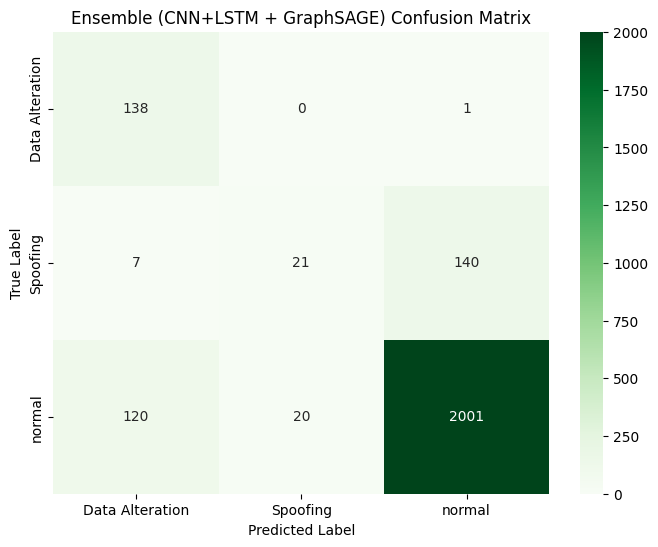


 ENSEMBLE BREAKDOWN FOR TEST SAMPLE 5277
Keras Probabilities   : [1. 0. 0.]
PyTorch Probabilities : [1.000e-04 6.690e-02 9.331e-01]
Ensemble Averaged     : [0.5    0.0334 0.4665]
--------------------------------------------------
Final Prediction      : DATA ALTERATION
Truth                 : DATA ALTERATION


In [17]:
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Commencing Ensemble (Late Fusion) ---")

# ==========================================
# 1. Get Probabilities from Keras (CNN+LSTM)
# ==========================================
# Using your new variable name for the Keras model
keras_probs = keras_model.predict(X_test_cnn, verbose=0)
print(f"Keras Probabilities Extracted: Shape {keras_probs.shape}")

# ==========================================
# 2. Get Probabilities from PyTorch (GraphSAGE)
# ==========================================
# Using the original 'model' variable name for GraphSAGE
model.eval()
with torch.no_grad():
    # Pass features and edges through GraphSAGE
    pytorch_out = model(data.x, data.edge_index)

    # Extract ONLY the test nodes
    pytorch_test_logits = pytorch_out[data.test_mask]

    # Apply Softmax to convert raw logits to probabilities
    pytorch_probs = F.softmax(pytorch_test_logits, dim=1).numpy()

print(f"PyTorch Probabilities Extracted: Shape {pytorch_probs.shape}")

# ==========================================
# 3. Combine (Average) the Probabilities
# ==========================================
ensemble_probs = (keras_probs + pytorch_probs) / 2.0
ensemble_preds = np.argmax(ensemble_probs, axis=1)

# ==========================================
# 4. Evaluate the Hybrid Ensemble
# ==========================================
ensemble_acc = np.mean(ensemble_preds == y_test)
print(f"\n🏆 FINAL ENSEMBLE TEST ACCURACY: {ensemble_acc * 100:.2f}% 🏆\n")

target_names = [str(c) for c in target_enc.classes_]

print("Classification Report on Ensemble Test Set:")
print(classification_report(y_test, ensemble_preds, target_names=target_names))

# Optional: Plot the Ensemble Confusion Matrix
cm = confusion_matrix(y_test, ensemble_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Ensemble (CNN+LSTM + GraphSAGE) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ==========================================
# 5. Check our Specific Test Sample!
# ==========================================
target_local_idx = np.where(idx_test == global_idx)[0][0]

keras_vote = keras_probs[target_local_idx]
pytorch_vote = pytorch_probs[target_local_idx]
ensemble_vote = ensemble_probs[target_local_idx]
final_pred_id = ensemble_preds[target_local_idx]
true_label_id = y_test[target_local_idx]

print("\n" + "="*50)
print(f" ENSEMBLE BREAKDOWN FOR TEST SAMPLE {global_idx}")
print("="*50)
print(f"Keras Probabilities   : {np.round(keras_vote, 4)}")
print(f"PyTorch Probabilities : {np.round(pytorch_vote, 4)}")
print(f"Ensemble Averaged     : {np.round(ensemble_vote, 4)}")
print("-" * 50)
print(f"Final Prediction      : {target_enc.classes_[final_pred_id].upper()}")
print(f"Truth                 : {target_enc.classes_[true_label_id].upper()}")
print("="*50)

 EXPLAINABLE AI ANALYSIS FOR ENSEMBLE TEST SAMPLE: 5277

[1/2] Generating SHAP Feature Importance for Keras CNN+LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 35, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 35, 1))']
  warnings.warn(msg)


-> Keras Predicted: DATA ALTERATION
-> Plotting Top 15 Features (SHAP)...


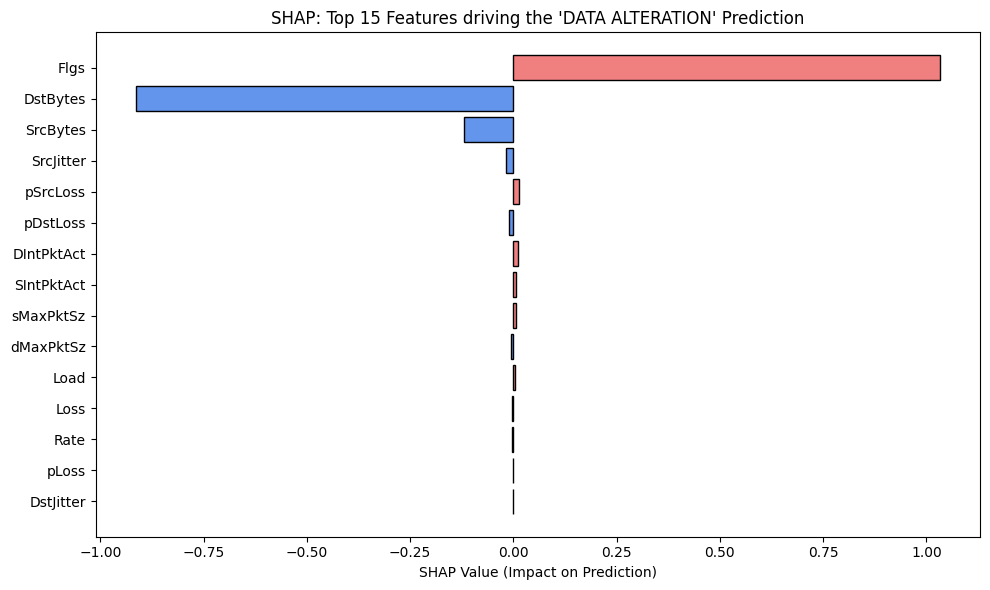


[2/2] Generating GNNExplainer for PyTorch GraphSAGE...


In [ ]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.explain import Explainer, GNNExplainer
from IPython.display import Image, display

print("="*60)
print(f" EXPLAINABLE AI ANALYSIS FOR ENSEMBLE TEST SAMPLE: {global_idx}")
print("="*60)

# ==============================================================================
# PART 1: SHAP EXPLANATION (KERAS CNN+LSTM)
# ==============================================================================
print("\n[1/2] Generating SHAP Feature Importance for Keras CNN+LSTM...")

# 1. Use 100 random training samples as the background baseline
background_idx = np.random.choice(X_train_cnn.shape[0], 100, replace=False)
background_data = X_train_cnn[background_idx]

# 2. Initialize GradientExplainer (best for complex Keras architectures)
keras_explainer = shap.GradientExplainer(keras_model, background_data)

# 3. Calculate SHAP values for the specific test sample
sample_to_explain = test_sample_3d
shap_values = keras_explainer.shap_values(sample_to_explain)

# 4. Extract and Visualize Safely
# 4. Extract and Visualize Safely
predicted_class = np.argmax(keras_model.predict(sample_to_explain, verbose=0))
predicted_class_name = target_enc.classes_[predicted_class].upper()

print(f"-> Keras Predicted: {predicted_class_name}")
print("-> Plotting Top 15 Features (SHAP)...")

# --- THE BUG FIX ---
# Re-sync the feature names with the dataframe used to train the model
feats = X_df.columns.tolist()

# Safely extract the SHAP values into a 1D array
if isinstance(shap_values, list):
    sv_1d = np.array(shap_values[predicted_class]).flatten()
else:
    # If SHAP returned a single multidimensional array
    if shap_values.shape[0] == len(target_enc.classes_):
        sv_1d = np.array(shap_values[predicted_class]).flatten()
    else:
        sv_1d = np.array(shap_values).flatten()

# Ensure we only grab values up to the number of features we have
sv_1d = sv_1d[:len(feats)]

# Get the indices of the Top 15 most important features (by magnitude)
top_indices = np.argsort(np.abs(sv_1d))[-15:]
top_shap_vals = sv_1d[top_indices]
top_feature_names = [feats[i] for i in top_indices]

# Plot using standard Matplotlib
plt.figure(figsize=(10, 6))
colors = ['lightcoral' if val > 0 else 'cornflowerblue' for val in top_shap_vals]
plt.barh(top_feature_names, top_shap_vals, color=colors, edgecolor='black')
plt.title(f"SHAP: Top 15 Features driving the '{predicted_class_name}' Prediction")
plt.xlabel("SHAP Value (Impact on Prediction)")
plt.tight_layout()
plt.show()

# ==============================================================================
# PART 2: GNN EXPLAINER (PYTORCH GRAPHSAGE)
# ==============================================================================
print("\n[2/2] Generating GNNExplainer for PyTorch GraphSAGE...")

# 1. Initialize PyTorch Geometric Explainer
gnn_explainer = Explainer(
    model=model,  # Your PyTorch GraphSAGE model
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes', # We want to know which Features mattered
    edge_mask_type='object',     # We want to know which Neighboring Packets mattered
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='raw',
    ),
)

# 2. Generate explanation for the exact same target node
# Restore the original 35-D raw features just for the Explainer
original_x = torch.tensor(X_scaled, dtype=torch.float)

# Generate explanation using the original raw features
explanation = gnn_explainer(original_x, data.edge_index, index=global_idx)
# 3. Plot GNN Feature Importance
print("-> Plotting GNNExplainer Feature Importance...")
try:
    explanation.visualize_feature_importance(top_k=10, feature_names=feats)
    plt.show()
except TypeError:
    # Fallback for some versions of PyG
    explanation.visualize_feature_importance(top_k=10)
    plt.show()



# Display the saved image inline in the Jupyter Notebook
display(Image(filename=graph_img_name))

print("\n" + "="*60)
print(" EXPLANATION COMPLETE! ")
print("="*60)

# **Feature Pipeline Method**

In [ ]:
from keras.models import Model

# Your model ends with: Dropout(126D) -> Dense(42D) -> Dense(Classes)
# So the Dropout layer is exactly 3 layers from the end (-3).
extractor = Model(inputs=keras_model.input, outputs=keras_model.layers[-3].output)

print("Extracting CNN+LSTM embeddings for the ENTIRE dataset...")
# Reshape the entire dataset to 3D so Keras can process it
X_all_cnn = X_scaled.reshape(-1, X_scaled.shape[1], 1)

# Generate the 126-D embeddings for every single packet
cnn_lstm_embeddings = extractor.predict(X_all_cnn, batch_size=256)

print(f"Extraction complete! New feature shape: {cnn_lstm_embeddings.shape}")

In [ ]:
import torch
import numpy as np

# DO NOT OVERWRITE! Concatenate the original raw features with the new embeddings.
# If original features = ~40, and embeddings = 126, combined = ~166 features!
combined_features = np.concatenate([X_scaled, cnn_lstm_embeddings], axis=1)

# Update the PyTorch Geometric data object
data.x = torch.tensor(combined_features, dtype=torch.float)

print(f"Graph Data Updated! Node features are now {data.x.shape[1]}-Dimensional.")

In [ ]:
import torch.optim as optim

# 1. Initialize a new GraphSAGE to accept 126-D input
model_graphsage_hybrid = GraphSAGE(num_features=data.x.shape[1], num_classes=len(np.unique(y)))
optimizer = optim.Adam(model_graphsage_hybrid.parameters(), lr=0.0012449, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

def train_hybrid():
    model_graphsage_hybrid.train()
    optimizer.zero_grad()

    # Passing the 126-D CNN+LSTM features through the Graph!
    out = model_graphsage_hybrid(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate_hybrid(mask):
    model_graphsage_hybrid.eval()
    with torch.no_grad():
        out = model_graphsage_hybrid(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        correct = (pred[mask] == data.y[mask]).sum().item()
        acc = correct / mask.sum().item()
    return acc

epochs = 300
print("Training Hybrid GraphSAGE (Feature Pipeline)...")
for epoch in range(1, epochs + 1):
    loss = train_hybrid()
    val_acc = evaluate_hybrid(data.val_mask)

    if epoch % 50 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}')

In [ ]:
from sklearn.metrics import classification_report
import torch.nn.functional as F

test_acc = evaluate_hybrid(data.test_mask)
print(f'\n HYBRID GRAPH TEST ACCURACY: {test_acc * 100:.2f}% \n')

# 1. Get predictions for the entire graph
model_graphsage_hybrid.eval()
with torch.no_grad():
    out = model_graphsage_hybrid(data.x, data.edge_index)

    # Extract test nodes and get predictions
    test_logits = out[data.test_mask]
    test_preds = test_logits.argmax(dim=1).numpy()

test_true = data.y[data.test_mask].numpy()
target_names = [str(c) for c in target_enc.classes_]

print("Classification Report on Hybrid GraphSAGE:")
print(classification_report(test_true, test_preds, target_names=target_names))

# ==========================================
# 2. Detailed Check of our Specific Example
# ==========================================
# We use the exact same 'global_idx' from the common preprocessing header
target_local_idx = np.where(idx_test == global_idx)[0][0]

# Extract the raw logits for this specific test node
sample_logits = test_logits[target_local_idx]

# Apply softmax to get the probability percentages
sample_probs = F.softmax(sample_logits, dim=0).numpy()

hybrid_pred = np.argmax(sample_probs)
true_label_id = test_true[target_local_idx]

print("\n" + "="*50)
print(f" HYBRID GRAPH BREAKDOWN FOR TEST SAMPLE {global_idx}")
print("="*50)
print(f"Hybrid Probabilities  : {np.round(sample_probs, 4)}")
print("-" * 50)
print(f"Final Prediction      : {target_enc.classes_[hybrid_pred].upper()}")
print(f"Truth                 : {target_enc.classes_[true_label_id].upper()}")
print("="*50)

In [ ]:
from torch_geometric.explain import Explainer, GNNExplainer
from IPython.display import Image, display

print("--- Initializing GNNExplainer for Hybrid Pipeline GraphSAGE ---")

hybrid_gnn_explainer = Explainer(
    model=model_graphsage_hybrid, # Your Approach 2 model
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    # Changed from None to 'object': This treats the entire 161-D embedding as ONE concept
    # to find out exactly WHICH neighbor nodes were most suspicious!
    node_mask_type='object',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='raw',
    ),
)

# Generate explanation for the exact same target node
hybrid_explanation = hybrid_gnn_explainer(data.x, data.edge_index, index=global_idx)

print("\nGenerating Hybrid Subgraph Explanation... (Saving to 'hybrid_subgraph_explanation.png')")

# This will draw the graph and color the neighboring nodes based on how important they were
graph_img_name2 = "hybrid_subgraph_explanation.png"
hybrid_explanation.visualize_graph(graph_img_name2)

# Display the saved image inline in the Jupyter Notebook
display(Image(filename=graph_img_name2))